In [1]:
#This second test uses voltage values for the plots instead of collected energies. This uses the ESR to generate a proper value for the collected voltage. 

#All of the imports
import sionna.rt
%matplotlib notebook
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import math
import drjit as dr
import mitsuba as mi
from typing import Tuple, List
import random 

from sionna.rt import load_scene, PlanarArray, Transmitter, Receiver, Camera,\
                      PathSolver, RadioMapSolver, subcarrier_frequencies

from tabulate import tabulate

#Where all the constants RF harvesting functions, and custom display functions are stored
import radio_functions

#Animation
import matplotlib.animation as animation

import matplotlib as mpl

using_preview = True



In [2]:
current_scene = load_scene("Blender2/UBC.xml")
current_scene.preview();

c:\Users\wonde\Documents\Extra_School_files\NSERC Research\UBC_tests\radio_functions.py:625: RuntimeWarning: overflow encountered in exp
  psig /= 1 + np.exp(-a*input_power + b)


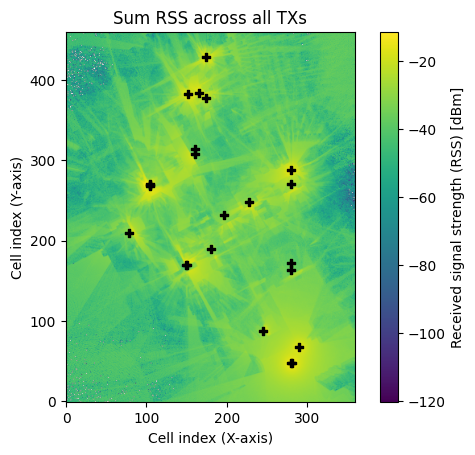

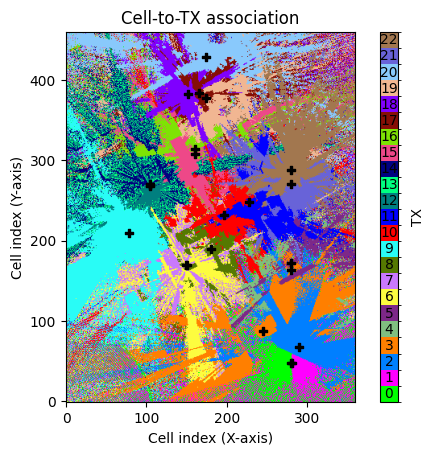

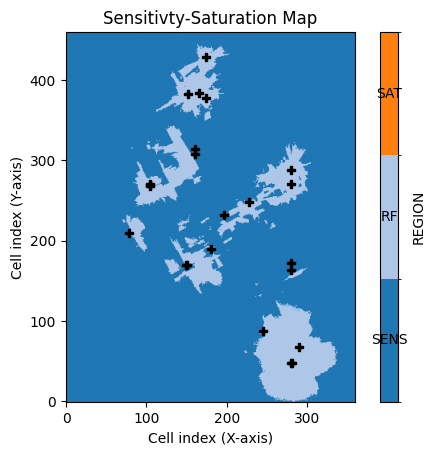

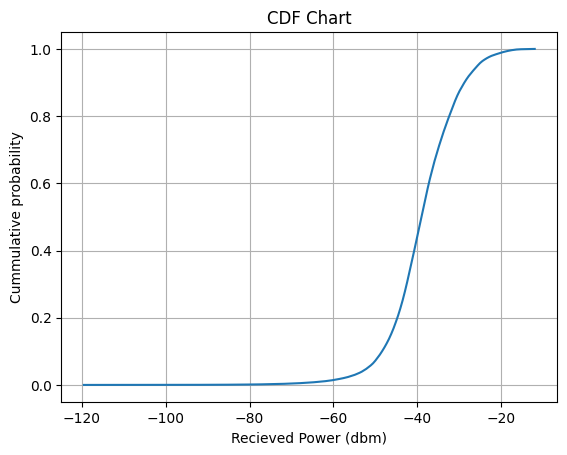

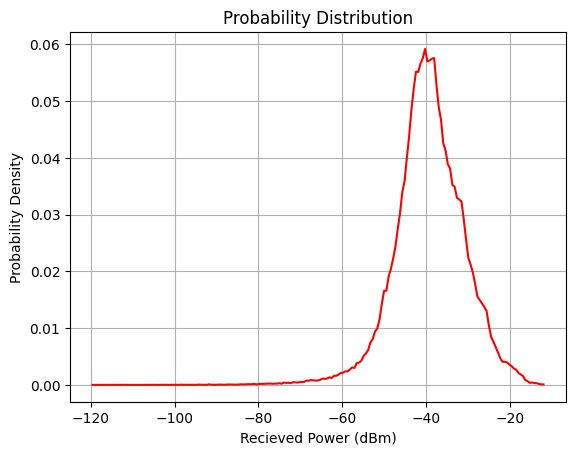

In [3]:
##Comparing Frequencies
current_scene.frequency = 1.0001e9
num_cols = 1
current_scene.tx_array = PlanarArray(num_rows=1,
                             num_cols=num_cols, 
                             vertical_spacing=0.5,
                             horizontal_spacing=0.5,
                             pattern="iso",
                             polarization="VH")


transmitters = []
positions_array = []

positions_array = [
    [500, -900, 27],
    [505, -900, 27],
    [550, -800, 27],
    [325, -700, 27],
    [500, -320, 27],
    [500, -280, 27],
    [-150, -290, 40],
    [-155, -290, 40],
    [0, -190, 20],
    [-510, -90, 27],
    [80, 20, 33],
    [240, 100, 27],
    [-380, 200, 27],
    [-380, 205, 27],
    [-380, 210, 27],
    [-100, 400, 30],
    [-100, 430, 30],
    [-70, 780, 30],
    [-140, 770, 30],
    [-30, 750, 30],
    [-30, 1000, 30],
    [500, 210, 27],
    [500, 300, 27]
]

sample_cell_positions = [
    [70, 240],
    [80, 360],
    [105,310],
    [116,270],
    [144,215],
    [173,165],
    [210,192],
    [160,280],
    [208,297]
]

for i,_position in enumerate(positions_array):
    transmitters.append(Transmitter(name=f"tx{i}", position=_position, display_radius=10, power_dbm=45))
    transmitters[-1].orientation = (random.random()*360, 0, 0)
    current_scene.add(transmitters[-1])
    
rm_solver = RadioMapSolver()
rm = rm_solver(current_scene,
               max_depth=30,           # Maximum number of ray scene interactions
               samples_per_tx=10**7 , # If you increase: less noise, but more memory required
               cell_size=(5, 5),      # Resolution of the radio map
               center=[0, 10, 1],      # Center of the radio map
               size=[1800, 2300],       # Total size of the radio map
               orientation=[0, 0, 0]) # Orientation of the radio map, e.g., could be also vertical


cdf_values = radio_functions.sum_cdf(rm, metric="rss");
metrics = radio_functions.calculate_metrics_from_cdf(cdf_values)


radio_functions.show_sum(rm, metric="rss")
radio_functions.show_association_more_colours(rm)
radio_functions.show_DC_regions(rm, metric="rss")


metrics.display_cdf_and_pdf(cdf_values[2])
current_scene.preview(radio_map=rm);

c:\Users\wonde\Documents\Extra_School_files\NSERC Research\UBC_tests\radio_functions.py:625: RuntimeWarning: overflow encountered in exp
  psig /= 1 + np.exp(-a*input_power + b)
c:\Users\wonde\Documents\Extra_School_files\NSERC Research\UBC_tests\radio_functions.py:625: RuntimeWarning: overflow encountered in exp
  psig /= 1 + np.exp(-a*input_power + b)
c:\Users\wonde\Documents\Extra_School_files\NSERC Research\UBC_tests\radio_functions.py:625: RuntimeWarning: overflow encountered in exp
  psig /= 1 + np.exp(-a*input_power + b)
c:\Users\wonde\Documents\Extra_School_files\NSERC Research\UBC_tests\radio_functions.py:625: RuntimeWarning: overflow encountered in exp
  psig /= 1 + np.exp(-a*input_power + b)
c:\Users\wonde\Documents\Extra_School_files\NSERC Research\UBC_tests\radio_functions.py:625: RuntimeWarning: overflow encountered in exp
  psig /= 1 + np.exp(-a*input_power + b)
c:\Users\wonde\Documents\Extra_School_files\NSERC Research\UBC_tests\radio_functions.py:625: RuntimeWarning: o

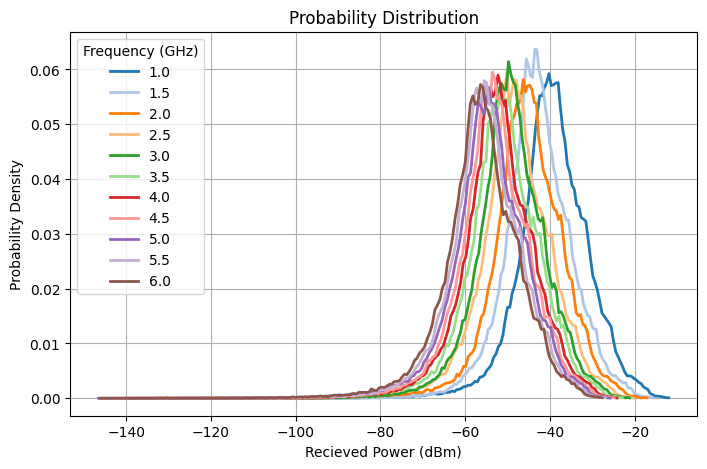

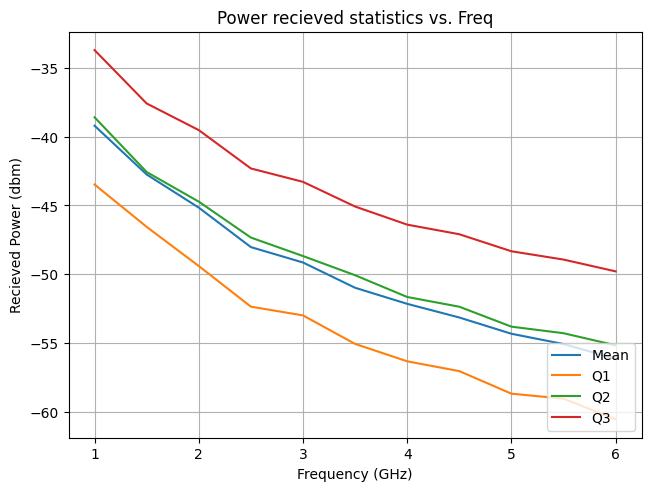

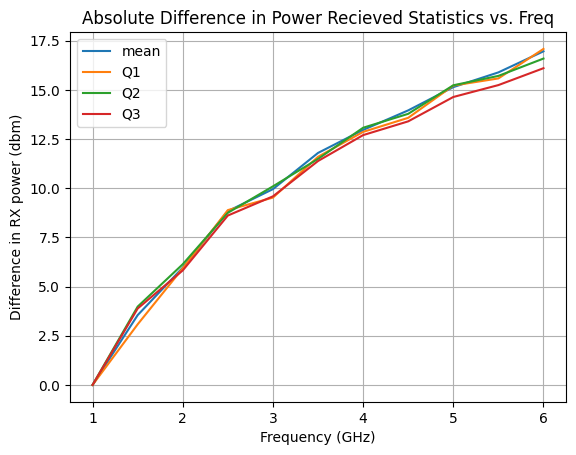

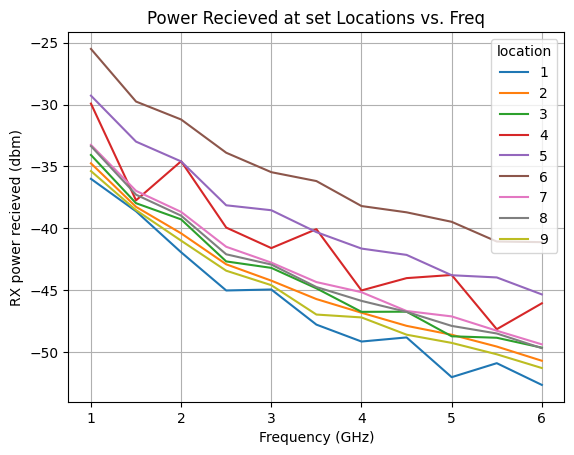

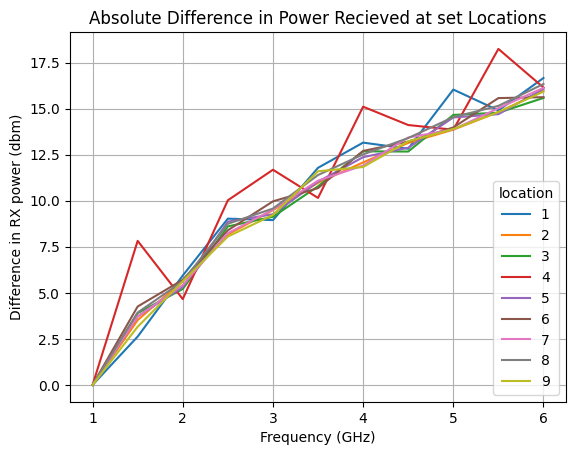

In [4]:
current_scene.frequency = 1.0001e9

pdf_array = []
pdf_array.append([metrics.pdf_power_values, metrics.pdf_values])

stats = [[],[],[],[]]
samples = []
for i in range(9):
    samples.append([])

stats[0].append(metrics.mean_energy_RX)
stats[2].append(metrics.median_energy_RX)
stats[1].append(metrics.first_qart_RX)
stats[3].append(metrics.third_quart_RX)

for i in range(9):
        samples[i].append(mi.Float(radio_functions.watt_to_dbm(radio_functions.sum_radio_map(rm, metric="rss")[sample_cell_positions[i][1]][sample_cell_positions[i][0]]))[0])


num_sensitivity_tests = 10
frequency_incrememnt = 5e8

for iteration in range(num_sensitivity_tests):
    current_scene.frequency += frequency_incrememnt
    
    rm = rm_solver(current_scene,
               max_depth=30,           # Maximum number of ray scene interactions
               samples_per_tx=10**7 , # If you increase: less noise, but more memory required
               cell_size=(5, 5),      # Resolution of the radio map
               center=[0, 10, 1],      # Center of the radio map
               size=[1800, 2300],       # Total size of the radio map
               orientation=[0, 0, 0]) # Orientation of the radio map, e.g., could be also vertical

    cdf_values = radio_functions.sum_cdf(rm, metric="rss");
    metrics = radio_functions.calculate_metrics_from_cdf(cdf_values)
    #metrics.display_cdf_and_pdf(cdf_values[2])

    #plt.plot(metrics.pdf_power_values, metrics.pdf_values, (255, 0, 0))
    #plt.show()
    pdf_array.append([metrics.pdf_power_values, metrics.pdf_values])
    stats[0].append(metrics.mean_energy_RX)
    stats[2].append(metrics.median_energy_RX)
    stats[1].append(metrics.first_qart_RX)
    stats[3].append(metrics.third_quart_RX)

    for i in range(9):
        samples[i].append(mi.Float(radio_functions.watt_to_dbm(radio_functions.sum_radio_map(rm, metric="rss")[sample_cell_positions[i][1]][sample_cell_positions[i][0]]))[0])


#plt.plot()
fig, ax = plt.subplots()

fig.subplots_adjust(0.01, 0.1, 0.99, 0.9, 0.85, 0.8)



ax.grid(True, which="both")
ax.set_ylabel("Probability Density")
ax.set_xlabel("Recieved Power (dBm)")
ax.set_title("Probability Distribution")

for i, val in enumerate(pdf_array):
    ax.plot(val[0], val[1], color=mpl.colormaps['tab20'].colors[i], linewidth=2.0, label=f"{1+i*.5}")

ax.legend(title="Frequency (GHz)")
    
plt.show()

##creating a bar plot
frequency_names = [f"{1+.5*i}" for i in range(num_sensitivity_tests+1)]
penguin_means = {
    'Mean': stats[0],
    'Q1': stats[1],
    'Q2': stats[2],
    'Q3': stats[3],
}


frequencies = [1+0.5*i for i in range(num_sensitivity_tests+1)]

fig, ax = plt.subplots(layout='constrained')

for attribute, measurement in penguin_means.items():
    rects = ax.plot(frequencies, measurement, label=attribute)

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_ylabel('Recieved Power (dbm)')
ax.set_xlabel('Frequency (GHz)')
ax.set_title("Power recieved statistics vs. Freq")
ax.legend(loc='lower right')
ax.grid(True, which="both")
#ax.set_ylim(-80, 0)

plt.show()


line_values = [np.array(stats[0])-stats[0][0], np.array(stats[1])-stats[1][0],np.array(stats[2])-stats[2][0],np.array(stats[3])-stats[3][0]]
line_values = np.abs(line_values)

fig, ax = plt.subplots()
labels = ["mean", "Q1", "Q2", "Q3"]

for i, line in enumerate(line_values):
    ax.plot(frequencies, line, label=labels[i])
ax.legend()
ax.grid(True, which="both")
ax.set_xlabel("Frequency (GHz)")
ax.set_ylabel("Difference in RX power (dbm)")
ax.set_title("Absolute Difference in Power Recieved Statistics vs. Freq")

plt.show()


fig, ax = plt.subplots()

for i, line in enumerate(samples):
    ax.plot(frequencies, line, label=f"{i+1}")
ax.legend(title="location")
ax.grid(True, which="both")
ax.set_xlabel("Frequency (GHz)")
ax.set_ylabel("RX power recieved (dbm)")
ax.set_title("Power Recieved at set Locations vs. Freq")

plt.show()



fig, ax = plt.subplots()

line_values = [np.array(arr)-arr[0] for arr in samples]
line_values = np.abs(line_values)

for i, line in enumerate(line_values):
    ax.plot(frequencies, line, label=f"{i+1}")
ax.legend(title="location")
ax.grid(True, which="both")
ax.set_xlabel("Frequency (GHz)")
ax.set_ylabel("Difference in RX power (dbm)")
ax.set_title("Absolute Difference in Power Recieved at set Locations")

plt.show()





c:\Users\wonde\Documents\Extra_School_files\NSERC Research\UBC_tests\radio_functions.py:625: RuntimeWarning: overflow encountered in exp
  psig /= 1 + np.exp(-a*input_power + b)
c:\Users\wonde\Documents\Extra_School_files\NSERC Research\UBC_tests\radio_functions.py:625: RuntimeWarning: overflow encountered in exp
  psig /= 1 + np.exp(-a*input_power + b)
c:\Users\wonde\Documents\Extra_School_files\NSERC Research\UBC_tests\radio_functions.py:625: RuntimeWarning: overflow encountered in exp
  psig /= 1 + np.exp(-a*input_power + b)
c:\Users\wonde\Documents\Extra_School_files\NSERC Research\UBC_tests\radio_functions.py:625: RuntimeWarning: overflow encountered in exp
  psig /= 1 + np.exp(-a*input_power + b)
c:\Users\wonde\Documents\Extra_School_files\NSERC Research\UBC_tests\radio_functions.py:625: RuntimeWarning: overflow encountered in exp
  psig /= 1 + np.exp(-a*input_power + b)
c:\Users\wonde\Documents\Extra_School_files\NSERC Research\UBC_tests\radio_functions.py:625: RuntimeWarning: o

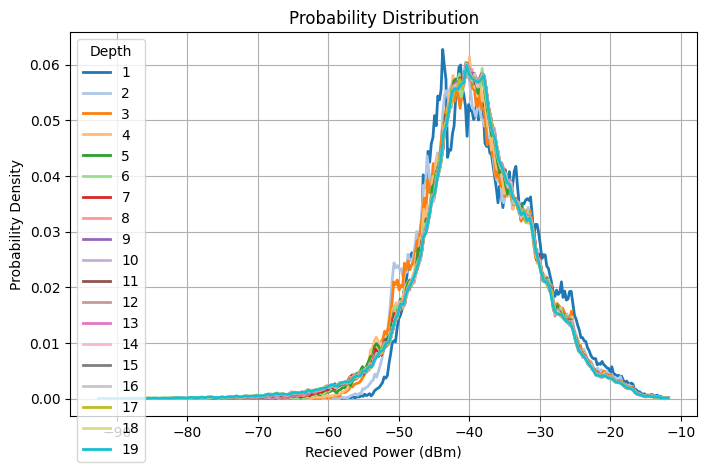

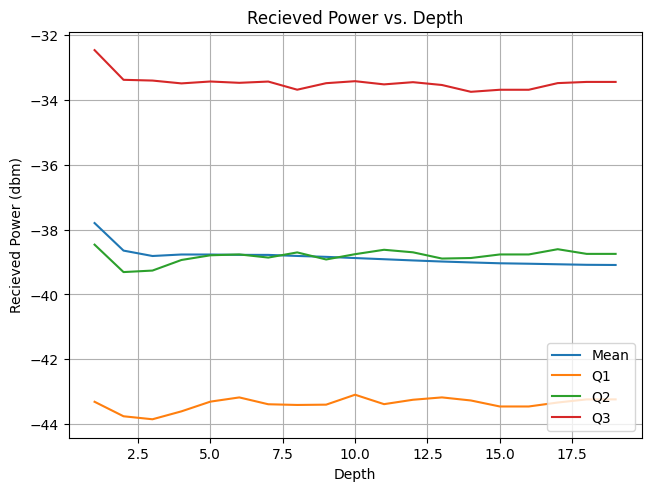

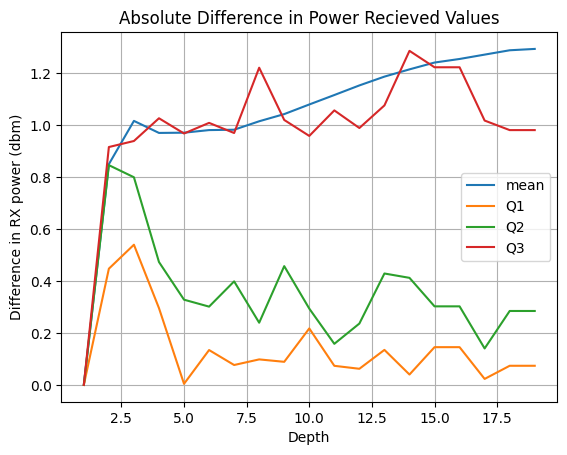

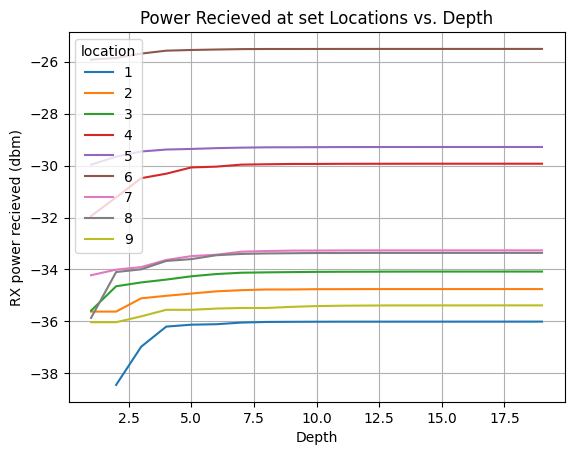

C:\Users\wonde\AppData\Local\Temp\ipykernel_40164\3222088982.py:123: RuntimeWarning: invalid value encountered in subtract
  line_values = [np.array(arr)-arr[0] for arr in samples]


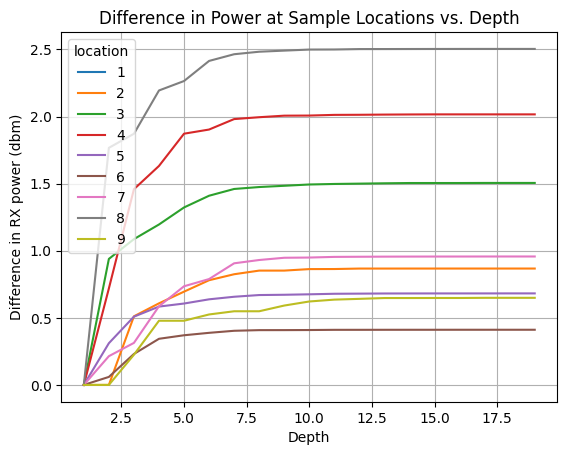

In [5]:
## Comparing Depth of Radio Map
current_scene.frequency = 1.0001e9

pdf_array = []
stats = [[],[],[],[]]

samples = []
for i in range(9):
    samples.append([])

num_sensitivity_tests = 19
depth_increment = 1
current_depth = 1

for iteration in range(num_sensitivity_tests):
    rm = rm_solver(current_scene,
               max_depth=current_depth,           # Maximum number of ray scene interactions
               samples_per_tx=10**7 , # If you increase: less noise, but more memory required
               cell_size=(5, 5),      # Resolution of the radio map
               center=[0, 10, 1],      # Center of the radio map
               size=[1800, 2300],       # Total size of the radio map
               orientation=[0, 0, 0]) # Orientation of the radio map, e.g., could be also vertical

    cdf_values = radio_functions.sum_cdf(rm, metric="rss");
    metrics = radio_functions.calculate_metrics_from_cdf(cdf_values)
    #metrics.display_cdf_and_pdf(cdf_values[2])

    #plt.plot(metrics.pdf_power_values, metrics.pdf_values, (255, 0, 0))
    #plt.show()
    pdf_array.append([metrics.pdf_power_values, metrics.pdf_values])
    stats[0].append(metrics.mean_energy_RX)
    stats[2].append(metrics.median_energy_RX)
    stats[1].append(metrics.first_qart_RX)
    stats[3].append(metrics.third_quart_RX)

    for i in range(9):
        samples[i].append(mi.Float(radio_functions.watt_to_dbm(radio_functions.sum_radio_map(rm, metric="rss")[sample_cell_positions[i][1]][sample_cell_positions[i][0]]))[0])


    current_depth += depth_increment

#plt.plot()
fig, ax = plt.subplots()

fig.subplots_adjust(0.01, 0.1, 0.99, 0.9, 0.85, 0.8)

#Makes an extended colour array by just looping the base array
color_array = [colour for colour in mpl.colormaps['tab20'].colors]
color_array.append(color_array)

ax.grid(True, which="both")
ax.set_ylabel("Probability Density")
ax.set_xlabel("Recieved Power (dBm)")
ax.set_title("Probability Distribution")

for i, val in enumerate(pdf_array):
    ax.plot(val[0], val[1], color=color_array[i], linewidth=2.0, label=f"{i+1}")

ax.legend(title="Depth")
    
plt.show()

##creating a bar plot
frequency_names = [f"{i+1}" for i in range(num_sensitivity_tests)]
penguin_means = {
    'Mean': stats[0],
    'Q1': stats[1],
    'Q2': stats[2],
    'Q3': stats[3],
}

frequencies = [i+1 for i in range(num_sensitivity_tests)]

fig, ax = plt.subplots(layout='constrained')

for attribute, measurement in penguin_means.items():
    rects = ax.plot(frequencies, measurement, label=attribute)

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_ylabel('Recieved Power (dbm)')
ax.set_xlabel('Depth')
ax.set_title("Recieved Power vs. Depth")
ax.legend(loc='lower right')
ax.grid(True, which="both")

plt.show()


line_values = [np.array(stats[0])-stats[0][0], np.array(stats[1])-stats[1][0],np.array(stats[2])-stats[2][0],np.array(stats[3])-stats[3][0]]
line_values = np.abs(line_values)

#frequencies = [i+1 for i in range(num_sensitivity_tests)]

fig, ax = plt.subplots()
labels = ["mean", "Q1", "Q2", "Q3"]

for i, line in enumerate(line_values):
    ax.plot(frequencies, line, label=labels[i])
ax.legend()
ax.grid(True, which="both")
ax.set_xlabel("Depth")
ax.set_ylabel("Difference in RX power (dbm)")
ax.set_title("Absolute Difference in Power Recieved Values")

plt.show()


fig, ax = plt.subplots()

for i, line in enumerate(samples):
    ax.plot(frequencies, line, label=f"{i+1}")
ax.legend(title="location")
ax.grid(True, which="both")
ax.set_xlabel("Depth")
ax.set_ylabel("RX power recieved (dbm)")
ax.set_title("Power Recieved at set Locations vs. Depth")

plt.show()


fig, ax = plt.subplots()

line_values = [np.array(arr)-arr[0] for arr in samples]
line_values = np.abs(line_values)

for i, line in enumerate(line_values):
    ax.plot(frequencies, line, label=f"{i+1}")
ax.legend(title="location")
ax.grid(True, which="both")
ax.set_xlabel("Depth")
ax.set_ylabel("Difference in RX power (dbm)")
ax.set_title("Difference in Power at Sample Locations vs. Depth")

plt.show()




c:\Users\wonde\Documents\Extra_School_files\NSERC Research\UBC_tests\radio_functions.py:625: RuntimeWarning: overflow encountered in exp
  psig /= 1 + np.exp(-a*input_power + b)
c:\Users\wonde\Documents\Extra_School_files\NSERC Research\UBC_tests\radio_functions.py:625: RuntimeWarning: overflow encountered in exp
  psig /= 1 + np.exp(-a*input_power + b)
c:\Users\wonde\Documents\Extra_School_files\NSERC Research\UBC_tests\radio_functions.py:625: RuntimeWarning: overflow encountered in exp
  psig /= 1 + np.exp(-a*input_power + b)
c:\Users\wonde\Documents\Extra_School_files\NSERC Research\UBC_tests\radio_functions.py:625: RuntimeWarning: overflow encountered in exp
  psig /= 1 + np.exp(-a*input_power + b)
c:\Users\wonde\Documents\Extra_School_files\NSERC Research\UBC_tests\radio_functions.py:625: RuntimeWarning: overflow encountered in exp
  psig /= 1 + np.exp(-a*input_power + b)
c:\Users\wonde\Documents\Extra_School_files\NSERC Research\UBC_tests\radio_functions.py:625: RuntimeWarning: o

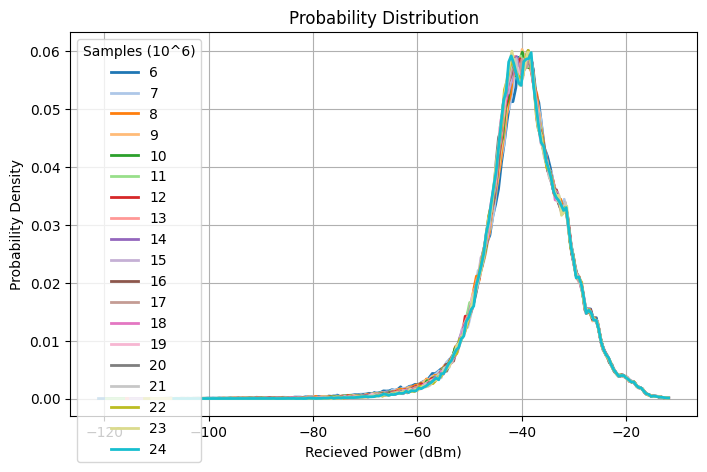

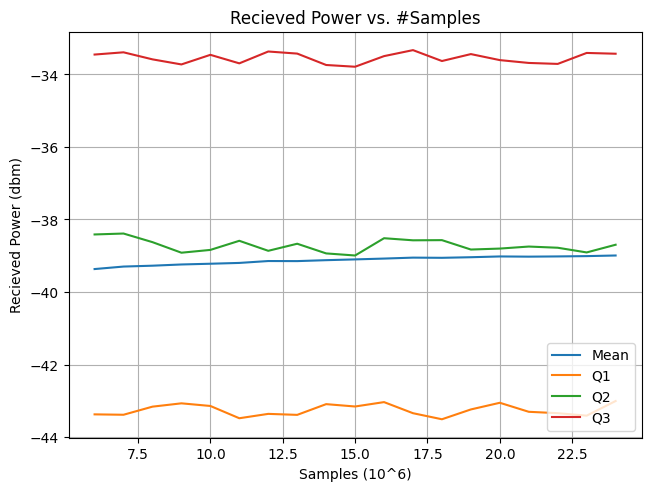

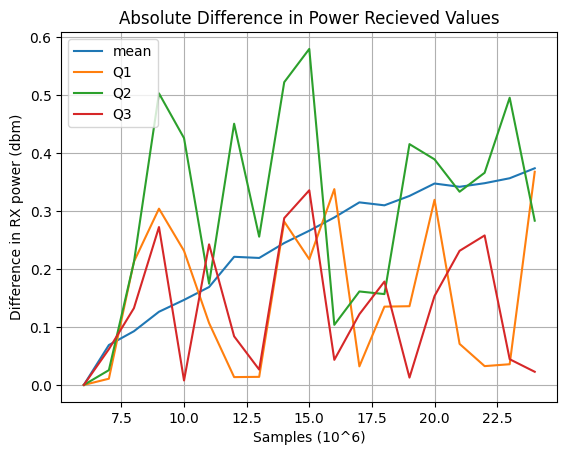

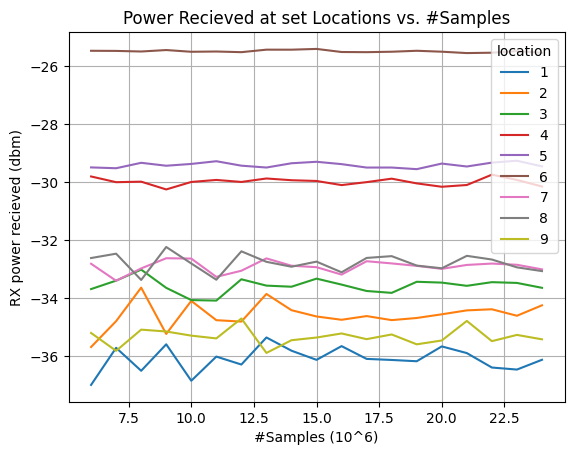

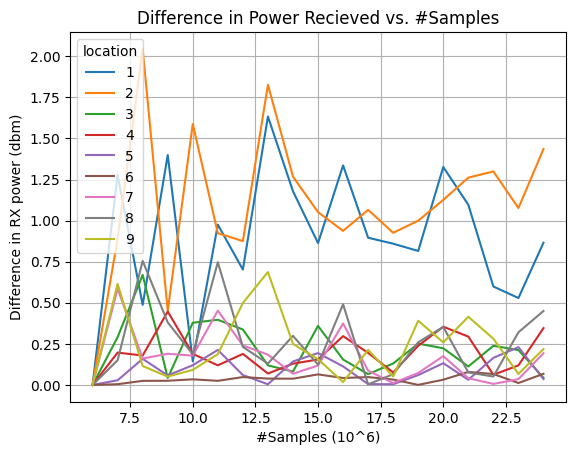

In [5]:
## Comparing Num Of Samples
current_scene.frequency = 1.0001e9

pdf_array = []
stats = [[],[],[],[]]

samples = []
for i in range(9):
    samples.append([])

num_sensitivity_tests = 19
samples_increment = 10**6
current_samples = 5*(10**6)

for iteration in range(num_sensitivity_tests):
    rm = rm_solver(current_scene,
               max_depth=30,           # Maximum number of ray scene interactions
               samples_per_tx=current_samples , # If you increase: less noise, but more memory required
               cell_size=(5, 5),      # Resolution of the radio map
               center=[0, 10, 1],      # Center of the radio map
               size=[1800, 2300],       # Total size of the radio map
               orientation=[0, 0, 0]) # Orientation of the radio map, e.g., could be also vertical

    cdf_values = radio_functions.sum_cdf(rm, metric="rss");
    metrics = radio_functions.calculate_metrics_from_cdf(cdf_values)
    #metrics.display_cdf_and_pdf(cdf_values[2])

    #plt.plot(metrics.pdf_power_values, metrics.pdf_values, (255, 0, 0))
    #plt.show()
    pdf_array.append([metrics.pdf_power_values, metrics.pdf_values])
    stats[0].append(metrics.mean_energy_RX)
    stats[2].append(metrics.median_energy_RX)
    stats[1].append(metrics.first_qart_RX)
    stats[3].append(metrics.third_quart_RX)

    for i in range(9):
        samples[i].append(mi.Float(radio_functions.watt_to_dbm(radio_functions.sum_radio_map(rm, metric="rss")[sample_cell_positions[i][1]][sample_cell_positions[i][0]]))[0])


    current_samples += samples_increment

#plt.plot()
fig, ax = plt.subplots()

fig.subplots_adjust(0.01, 0.1, 0.99, 0.9, 0.85, 0.8)

#Makes an extended colour array by just looping the base array
color_array = [colour for colour in mpl.colormaps['tab20'].colors]
color_array.append(color_array)

ax.grid(True, which="both")
ax.set_ylabel("Probability Density")
ax.set_xlabel("Recieved Power (dBm)")
ax.set_title("Probability Distribution")

for i, val in enumerate(pdf_array):
    ax.plot(val[0], val[1], color=color_array[i], linewidth=2.0, label=f"{(i+6)}")

ax.legend(title="Samples (10^6)")
    
plt.show()

##creating a bar plot
frequency_names = [f"{i+6}" for i in range(num_sensitivity_tests)]
penguin_means = {
    'Mean': stats[0],
    'Q1': stats[1],
    'Q2': stats[2],
    'Q3': stats[3],
}

frequencies = [i+6 for i in range(num_sensitivity_tests)]

fig, ax = plt.subplots(layout='constrained')

for attribute, measurement in penguin_means.items():
    rects = ax.plot(frequencies, measurement, label=attribute)

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_ylabel('Recieved Power (dbm)')
ax.set_xlabel('Samples (10^6)')
ax.legend(loc='lower right')
ax.grid(True, which="both")
ax.set_title("Recieved Power vs. #Samples")

plt.show()


line_values = [np.array(stats[0])-stats[0][0], np.array(stats[1])-stats[1][0],np.array(stats[2])-stats[2][0],np.array(stats[3])-stats[3][0]]
line_values = np.abs(line_values)

fig, ax = plt.subplots()
labels = ["mean", "Q1", "Q2", "Q3"]

for i, line in enumerate(line_values):
    ax.plot(frequencies, line, label=labels[i])
ax.legend()
ax.grid(True, which="both")
ax.set_xlabel("Samples (10^6)")
ax.set_ylabel("Difference in RX power (dbm)")
ax.set_title("Absolute Difference in Power Recieved Values")

plt.show()

fig, ax = plt.subplots()

for i, line in enumerate(samples):
    ax.plot(frequencies, line, label=f"{i+1}")
ax.legend(title="location")
ax.grid(True, which="both")
ax.set_xlabel("#Samples (10^6)")
ax.set_ylabel("RX power recieved (dbm)")
ax.set_title("Power Recieved at set Locations vs. #Samples")

plt.show()

fig, ax = plt.subplots()

line_values = [np.array(arr)-arr[0] for arr in samples]
line_values = np.abs(line_values)

for i, line in enumerate(line_values):
    ax.plot(frequencies, line, label=f"{i+1}")
ax.legend(title="location")
ax.grid(True, which="both")
ax.set_xlabel("#Samples (10^6)")
ax.set_ylabel("Difference in RX power (dbm)")
ax.set_title("Difference in Power Recieved vs. #Samples")

plt.show()



c:\Users\wonde\Documents\Extra_School_files\NSERC Research\UBC_tests\radio_functions.py:625: RuntimeWarning: overflow encountered in exp
  psig /= 1 + np.exp(-a*input_power + b)
c:\Users\wonde\Documents\Extra_School_files\NSERC Research\UBC_tests\radio_functions.py:625: RuntimeWarning: overflow encountered in exp
  psig /= 1 + np.exp(-a*input_power + b)
c:\Users\wonde\Documents\Extra_School_files\NSERC Research\UBC_tests\radio_functions.py:625: RuntimeWarning: overflow encountered in exp
  psig /= 1 + np.exp(-a*input_power + b)
c:\Users\wonde\Documents\Extra_School_files\NSERC Research\UBC_tests\radio_functions.py:625: RuntimeWarning: overflow encountered in exp
  psig /= 1 + np.exp(-a*input_power + b)
c:\Users\wonde\Documents\Extra_School_files\NSERC Research\UBC_tests\radio_functions.py:625: RuntimeWarning: overflow encountered in exp
  psig /= 1 + np.exp(-a*input_power + b)


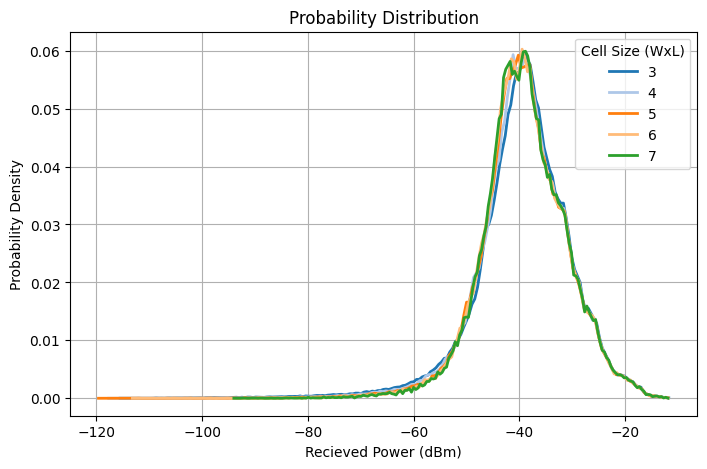

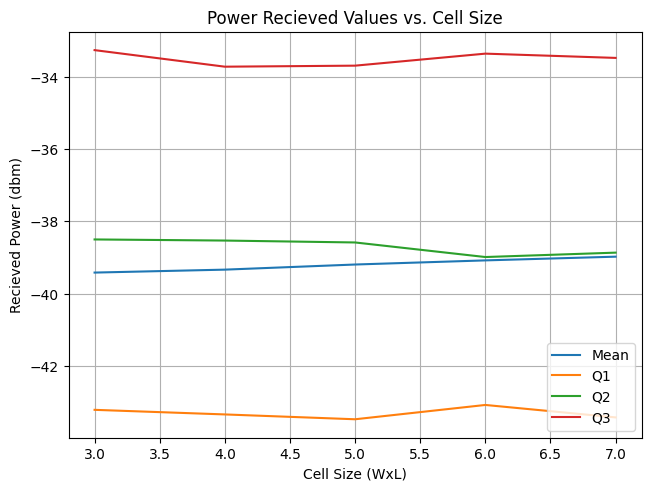

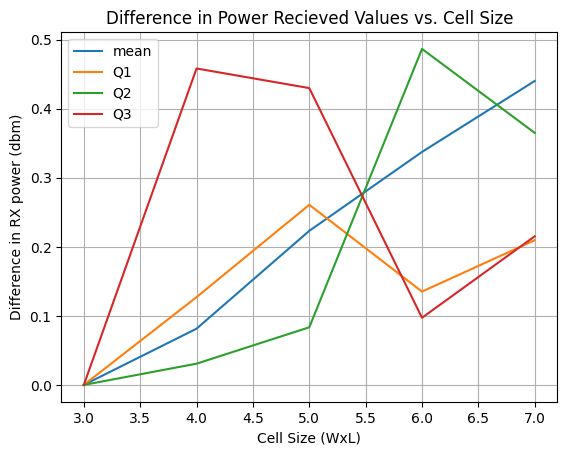

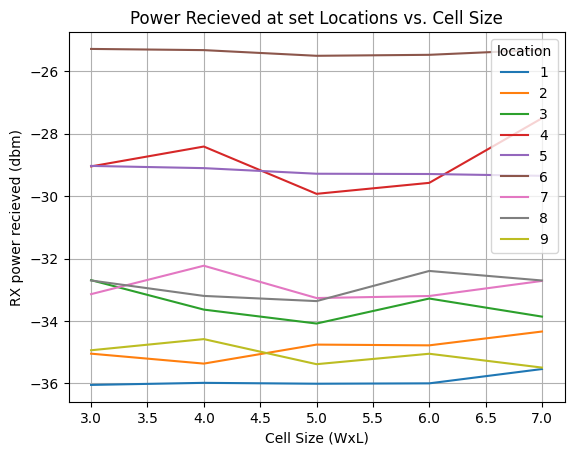

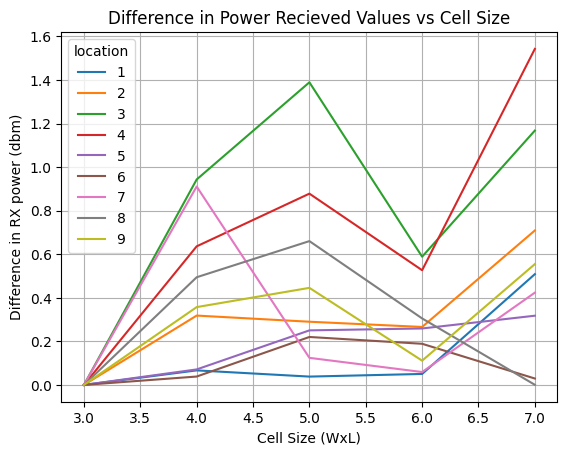

In [7]:
##Testing Cell Size
current_scene.frequency = 1.0001e9

pdf_array = []
stats = [[],[],[],[]]

samples = []
for i in range(9):
    samples.append([])

num_sensitivity_tests = 5
size_increment = 1
current_size = 3

for iteration in range(num_sensitivity_tests):
    rm = rm_solver(current_scene,
               max_depth=30,           # Maximum number of ray scene interactions
               samples_per_tx=10**7 , # If you increase: less noise, but more memory required
               cell_size=(current_size, current_size),      # Resolution of the radio map
               center=[0, 10, 1],      # Center of the radio map
               size=[1800, 2300],       # Total size of the radio map
               orientation=[0, 0, 0]) # Orientation of the radio map, e.g., could be also vertical

    cdf_values = radio_functions.sum_cdf(rm, metric="rss");
    metrics = radio_functions.calculate_metrics_from_cdf(cdf_values)
    #metrics.display_cdf_and_pdf(cdf_values[2])

    #plt.plot(metrics.pdf_power_values, metrics.pdf_values, (255, 0, 0))
    #plt.show()
    pdf_array.append([metrics.pdf_power_values, metrics.pdf_values])
    stats[0].append(metrics.mean_energy_RX)
    stats[2].append(metrics.median_energy_RX)
    stats[1].append(metrics.first_qart_RX)
    stats[3].append(metrics.third_quart_RX)

    

    for i in range(9):
        samples[i].append(mi.Float(radio_functions.watt_to_dbm(radio_functions.sum_radio_map(rm, metric="rss")[int(sample_cell_positions[i][1] * (5)/current_size)][int(sample_cell_positions[i][0] * (5)/current_size)]))[0])

    current_size += size_increment

#plt.plot()
fig, ax = plt.subplots()

fig.subplots_adjust(0.01, 0.1, 0.99, 0.9, 0.85, 0.8)

#Makes an extended colour array by just looping the base array
color_array = [colour for colour in mpl.colormaps['tab20'].colors]
color_array.append(color_array)

ax.grid(True, which="both")
ax.set_ylabel("Probability Density")
ax.set_xlabel("Recieved Power (dBm)")
ax.set_title("Probability Distribution")

for i, val in enumerate(pdf_array):
    ax.plot(val[0], val[1], color=color_array[i], linewidth=2.0, label=f"{(i+3)}")

ax.legend(title="Cell Size (WxL)")
    
plt.show()

##creating a bar plot
frequency_names = [f"{i+3}" for i in range(num_sensitivity_tests)]
penguin_means = {
    'Mean': stats[0],
    'Q1': stats[1],
    'Q2': stats[2],
    'Q3': stats[3],
}

frequencies = [i+3 for i in range(num_sensitivity_tests)]

fig, ax = plt.subplots(layout='constrained')

for attribute, measurement in penguin_means.items():
    rects = ax.plot(frequencies, measurement, label=attribute)

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_ylabel('Recieved Power (dbm)')
ax.set_xlabel('Cell Size (WxL)')
ax.set_title("Power Recieved Values vs. Cell Size")
ax.legend(loc='lower right')
ax.grid(True, which="both")

plt.show()


line_values = [np.array(stats[0])-stats[0][0], np.array(stats[1])-stats[1][0],np.array(stats[2])-stats[2][0],np.array(stats[3])-stats[3][0]]
line_values = np.abs(line_values)

fig, ax = plt.subplots()
labels = ["mean", "Q1", "Q2", "Q3"]

for i, line in enumerate(line_values):
    ax.plot(frequencies, line, label=labels[i])
ax.legend()
ax.grid(True, which="both")
ax.set_xlabel("Cell Size (WxL)")
ax.set_ylabel("Difference in RX power (dbm)")
ax.set_title("Difference in Power Recieved Values vs. Cell Size")

plt.show()

fig, ax = plt.subplots()

for i, line in enumerate(samples):
    ax.plot(frequencies, line, label=f"{i+1}")
ax.legend(title="location")
ax.grid(True, which="both")
ax.set_xlabel("Cell Size (WxL)")
ax.set_ylabel("RX power recieved (dbm)")
ax.set_title("Power Recieved at set Locations vs. Cell Size")

plt.show()


fig, ax = plt.subplots()

line_values = [np.array(arr)-arr[0] for arr in samples]
line_values = np.abs(line_values)

for i, line in enumerate(line_values):
    ax.plot(frequencies, line, label=f"{i+1}")
ax.legend(title="location")
ax.grid(True, which="both")
ax.set_xlabel("Cell Size (WxL)")
ax.set_ylabel("Difference in RX power (dbm)")
ax.set_title("Difference in Power Recieved Values vs Cell Size")

plt.show()


glass


c:\Users\wonde\Documents\Extra_School_files\NSERC Research\UBC_tests\radio_functions.py:625: RuntimeWarning: overflow encountered in exp
  psig /= 1 + np.exp(-a*input_power + b)


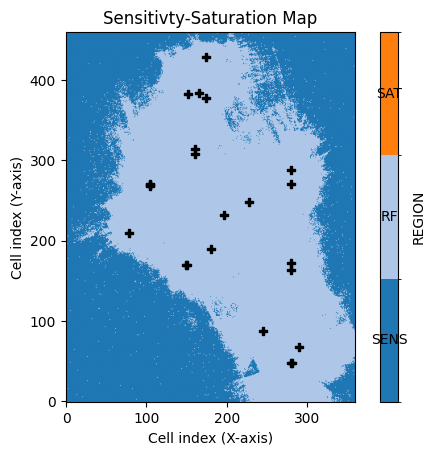

marble


c:\Users\wonde\Documents\Extra_School_files\NSERC Research\UBC_tests\radio_functions.py:625: RuntimeWarning: overflow encountered in exp
  psig /= 1 + np.exp(-a*input_power + b)


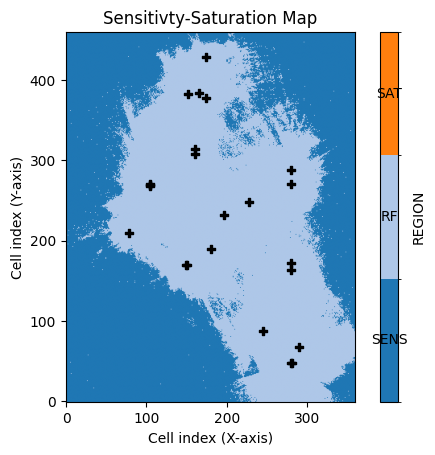

c:\Users\wonde\Documents\Extra_School_files\NSERC Research\UBC_tests\radio_functions.py:625: RuntimeWarning: overflow encountered in exp
  psig /= 1 + np.exp(-a*input_power + b)


wood


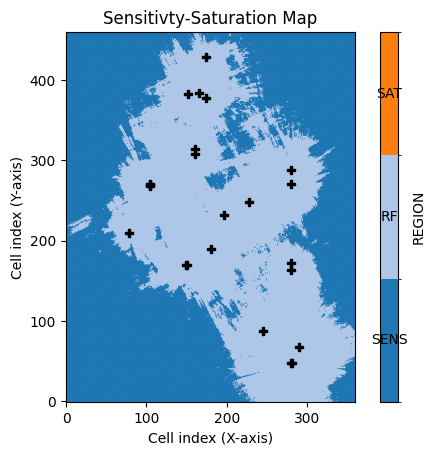

metal


c:\Users\wonde\Documents\Extra_School_files\NSERC Research\UBC_tests\radio_functions.py:625: RuntimeWarning: overflow encountered in exp
  psig /= 1 + np.exp(-a*input_power + b)


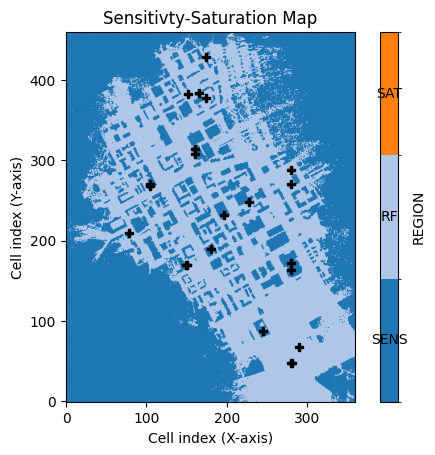

c:\Users\wonde\Documents\Extra_School_files\NSERC Research\UBC_tests\radio_functions.py:625: RuntimeWarning: overflow encountered in exp
  psig /= 1 + np.exp(-a*input_power + b)


brick


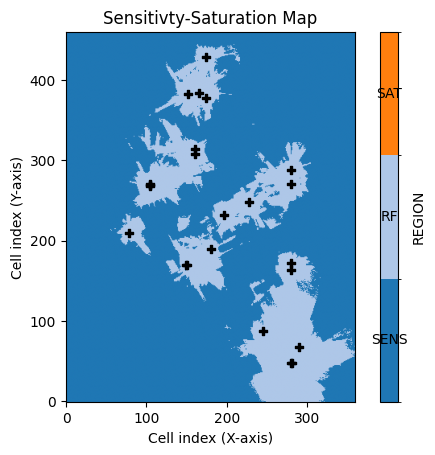

c:\Users\wonde\Documents\Extra_School_files\NSERC Research\UBC_tests\radio_functions.py:625: RuntimeWarning: overflow encountered in exp
  psig /= 1 + np.exp(-a*input_power + b)


plywood


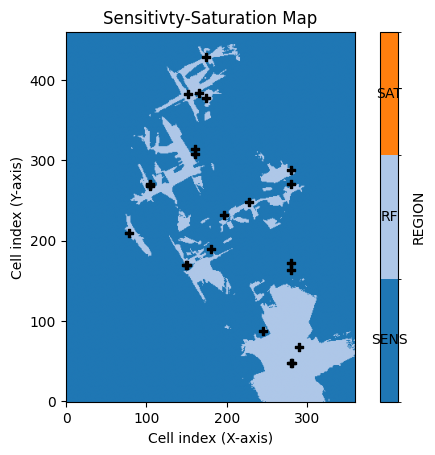

c:\Users\wonde\Documents\Extra_School_files\NSERC Research\UBC_tests\radio_functions.py:625: RuntimeWarning: overflow encountered in exp
  psig /= 1 + np.exp(-a*input_power + b)


celboard


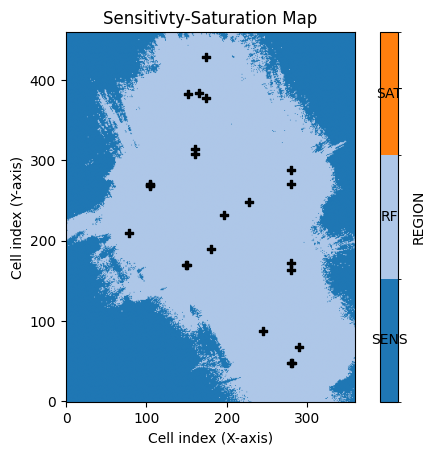

chipbrd


c:\Users\wonde\Documents\Extra_School_files\NSERC Research\UBC_tests\radio_functions.py:625: RuntimeWarning: overflow encountered in exp
  psig /= 1 + np.exp(-a*input_power + b)


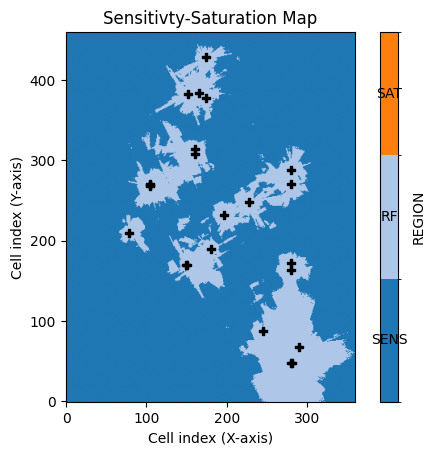

concrete


c:\Users\wonde\Documents\Extra_School_files\NSERC Research\UBC_tests\radio_functions.py:625: RuntimeWarning: overflow encountered in exp
  psig /= 1 + np.exp(-a*input_power + b)


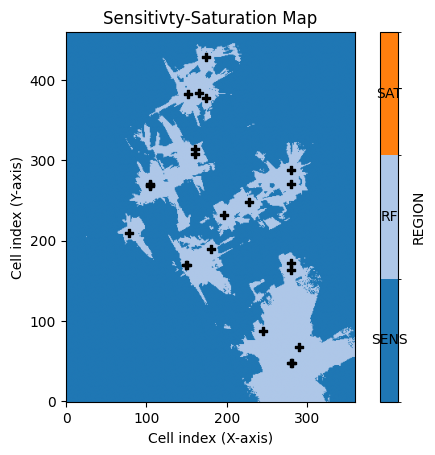

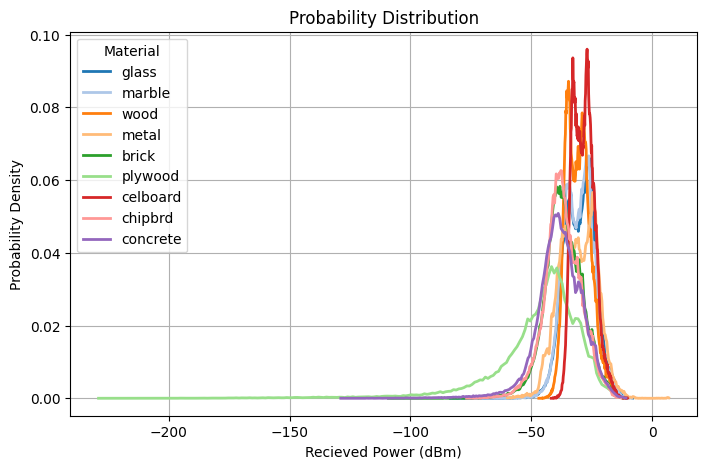

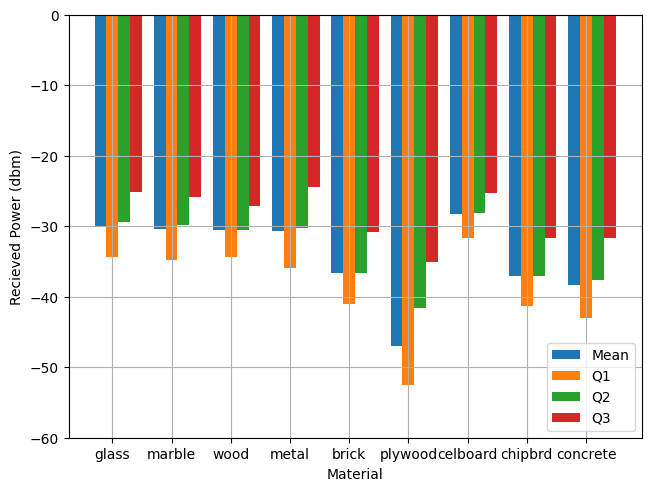

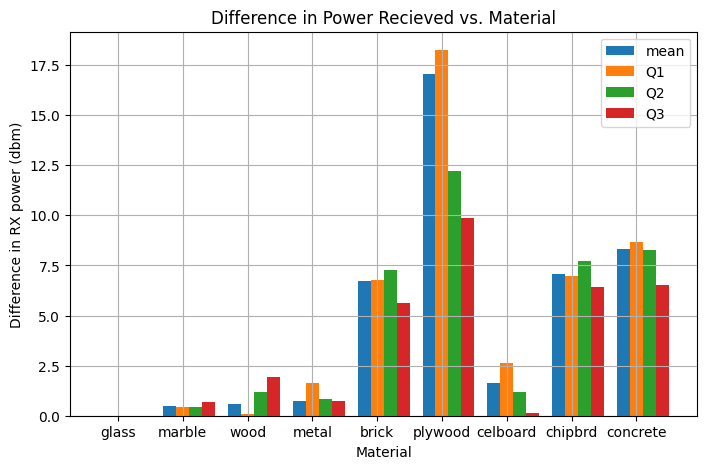

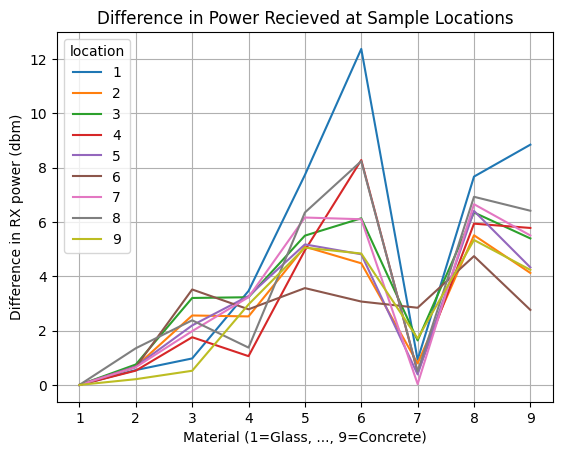

: 

In [ ]:
##Testing Materials
current_scene.frequency = 1.0001e9

pdf_array = []
stats = [[],[],[],[]]

samples = []
for i in range(9):
    samples.append([])

num_sensitivity_tests = 9

materials_array = []
materials_array.append(sionna.rt.ITURadioMaterial("glass", "glass", thickness=0.1))
materials_array.append(sionna.rt.ITURadioMaterial("marble", "marble", thickness=0.1))
materials_array.append(sionna.rt.ITURadioMaterial("wood", "wood", thickness=0.1))
materials_array.append(sionna.rt.ITURadioMaterial("metal", "metal", thickness=0.1))
materials_array.append(sionna.rt.ITURadioMaterial("brick", "brick", thickness=0.1))
materials_array.append(sionna.rt.ITURadioMaterial("plywood", "plywood", thickness=0.1))
materials_array.append(sionna.rt.ITURadioMaterial("celboard", "ceiling_board", thickness=0.1))
materials_array.append(sionna.rt.ITURadioMaterial("chipbrd", "chipboard", thickness=0.1))
materials_array.append(sionna.rt.ITURadioMaterial("concrete", "concrete", thickness=0.1))

material_names = [radiomat.name for radiomat in materials_array]

for iteration in range(num_sensitivity_tests):
    for name, obj in current_scene.objects.items():
        obj.radio_material = materials_array[iteration]

    rm = rm_solver(current_scene,
               max_depth=30,           # Maximum number of ray scene interactions
               samples_per_tx=10**7 , # If you increase: less noise, but more memory required
               cell_size=(5, 5),      # Resolution of the radio map
               center=[0, 10, 1],      # Center of the radio map
               size=[1800, 2300],       # Total size of the radio map
               orientation=[0, 0, 0]) # Orientation of the radio map, e.g., could be also vertical

    cdf_values = radio_functions.sum_cdf(rm, metric="rss");
    metrics = radio_functions.calculate_metrics_from_cdf(cdf_values)
    #metrics.display_cdf_and_pdf(cdf_values[2])

    #plt.plot(metrics.pdf_power_values, metrics.pdf_values, (255, 0, 0))
    #plt.show()
    pdf_array.append([metrics.pdf_power_values, metrics.pdf_values])
    stats[0].append(metrics.mean_energy_RX)
    stats[2].append(metrics.median_energy_RX)
    stats[1].append(metrics.first_qart_RX)
    stats[3].append(metrics.third_quart_RX)

    for i in range(9):
        samples[i].append(mi.Float(radio_functions.watt_to_dbm(radio_functions.sum_radio_map(rm, metric="rss")[sample_cell_positions[i][1]][sample_cell_positions[i][0]]))[0])


    print(material_names[iteration])
    radio_functions.show_DC_regions(rm, metric="rss")


#plt.plot()
fig, ax = plt.subplots()

fig.subplots_adjust(0.01, 0.1, 0.99, 0.9, 0.85, 0.8)

#Makes an extended colour array by just looping the base array
color_array = [colour for colour in mpl.colormaps['tab20'].colors]
color_array.append(color_array)

ax.grid(True, which="both")
ax.set_ylabel("Probability Density")
ax.set_xlabel("Recieved Power (dBm)")
ax.set_title("Probability Distribution")


for i, val in enumerate(pdf_array):
    ax.plot(val[0], val[1], color=color_array[i], linewidth=2.0, label=material_names[i])

ax.legend(title="Material")
    
plt.show()

##creating a bar plot
frequency_names = [material_names[i] for i in range(num_sensitivity_tests)]
penguin_means = {
    'Mean': stats[0],
    'Q1': stats[1],
    'Q2': stats[2],
    'Q3': stats[3],
}

width = 0.25  # the width of the bars
x = np.arange(len(material_names[i])+1) * (5*width)  # the label locations
multiplier = 0

fig, ax = plt.subplots(layout='constrained')

for attribute, measurement in penguin_means.items():
    offset = width * multiplier
    rects = ax.bar(x + offset, measurement, width, label=attribute)
    multiplier += 1

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.grid(True, which="both")
ax.set_ylabel('Recieved Power (dbm)')
ax.set_xlabel('Material')
ax.set_xticks(x + width, material_names)
ax.legend(loc='lower right')
ax.set_ylim(-60, 0)

plt.show()


line_values = [np.array(stats[0])-stats[0][0], np.array(stats[1])-stats[1][0],np.array(stats[2])-stats[2][0],np.array(stats[3])-stats[3][0]]
line_values = np.abs(line_values)

fig, ax = plt.subplots()
labels = ["mean", "Q1", "Q2", "Q3"]

multiplier = 0

for i, line in enumerate(line_values):
    offset = width * multiplier
    rects = ax.bar(x + offset, line, width, label=labels[i])
    multiplier += 1

ax.legend()
ax.grid(True, which="both")
ax.set_xlabel("Material")
ax.set_ylabel("Difference in RX power (dbm)")
ax.set_xticks(x + width, material_names)
ax.set_title("Difference in Power Recieved vs. Material")
fig.subplots_adjust(0.01, 0.1, 0.99, 0.9, 0.85, 0.8)

plt.show()

fig, ax = plt.subplots()

line_values = [np.array(arr)-arr[0] for arr in samples]
line_values = np.abs(line_values)


frequencies = [i+1 for i in range(len(line_values))]

for i, line in enumerate(line_values):
    ax.plot(frequencies, line, label=f"{i+1}")
ax.legend(title="location")
ax.grid(True, which="both")
ax.set_xlabel("Material (1=Glass, ..., 9=Concrete)")
ax.set_ylabel("Difference in RX power (dbm)")
ax.set_title("Difference in Power Recieved at Sample Locations")

plt.show()


